In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import pandas as pd
import os
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


C:\Users\alvarodela.herran\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\alvarodela.herran\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## CHARGE THE DATASET


In [3]:
# Set the path to the file you'd like to load
file_path = "retail_customer_segmentation.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rohit8527kmr7518/online-retail-customer-classification-dataset",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())


C:\Users\alvarodela.herran\AppData\Local\Temp\ipykernel_7528\4068559670.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    customer_id  age  annual_income  months_active  avg_monthly_spend  \
0        33554   53  100473.211709             63         121.430565   
1         9428   54   54730.644845             67         572.552674   
2          200   44   58268.121079             57         266.593896   
3        12448   54   64829.795654             40         691.452358   
4        39490   28   27431.467873             15         832.664792   

   purchase_frequency  avg_order_value  discount_usage_rate  return_rate  \
0            0.817268        66.820403             0.117256     0.023144   
1            3.176551       137.087449             0.261647     0.429054   
2            2.713168        71.796888             0.284785     0.011854   
3            5.553977       105.501185             0.104832     0.399686   
4            1.348389       354.568534             0.409204     0.039517   

   browsing_time_minutes  support_interactions payment_method      region  \
0              7

Dataset Shape: (50000, 14)

First 5 Rows:
   customer_id  age  annual_income  months_active  avg_monthly_spend  \
0        33554   53  100473.211709             63         121.430565   
1         9428   54   54730.644845             67         572.552674   
2          200   44   58268.121079             57         266.593896   
3        12448   54   64829.795654             40         691.452358   
4        39490   28   27431.467873             15         832.664792   

   purchase_frequency  avg_order_value  discount_usage_rate  return_rate  \
0            0.817268        66.820403             0.117256     0.023144   
1            3.176551       137.087449             0.261647     0.429054   
2            2.713168        71.796888             0.284785     0.011854   
3            5.553977       105.501185             0.104832     0.399686   
4            1.348389       354.568534             0.409204     0.039517   

   browsing_time_minutes  support_interactions payment_method      r

C:\Users\alvarodela.herran\AppData\Local\Temp\ipykernel_7528\2798377536.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='customer_segment', y='avg_monthly_spend', data=df, palette='Set2')


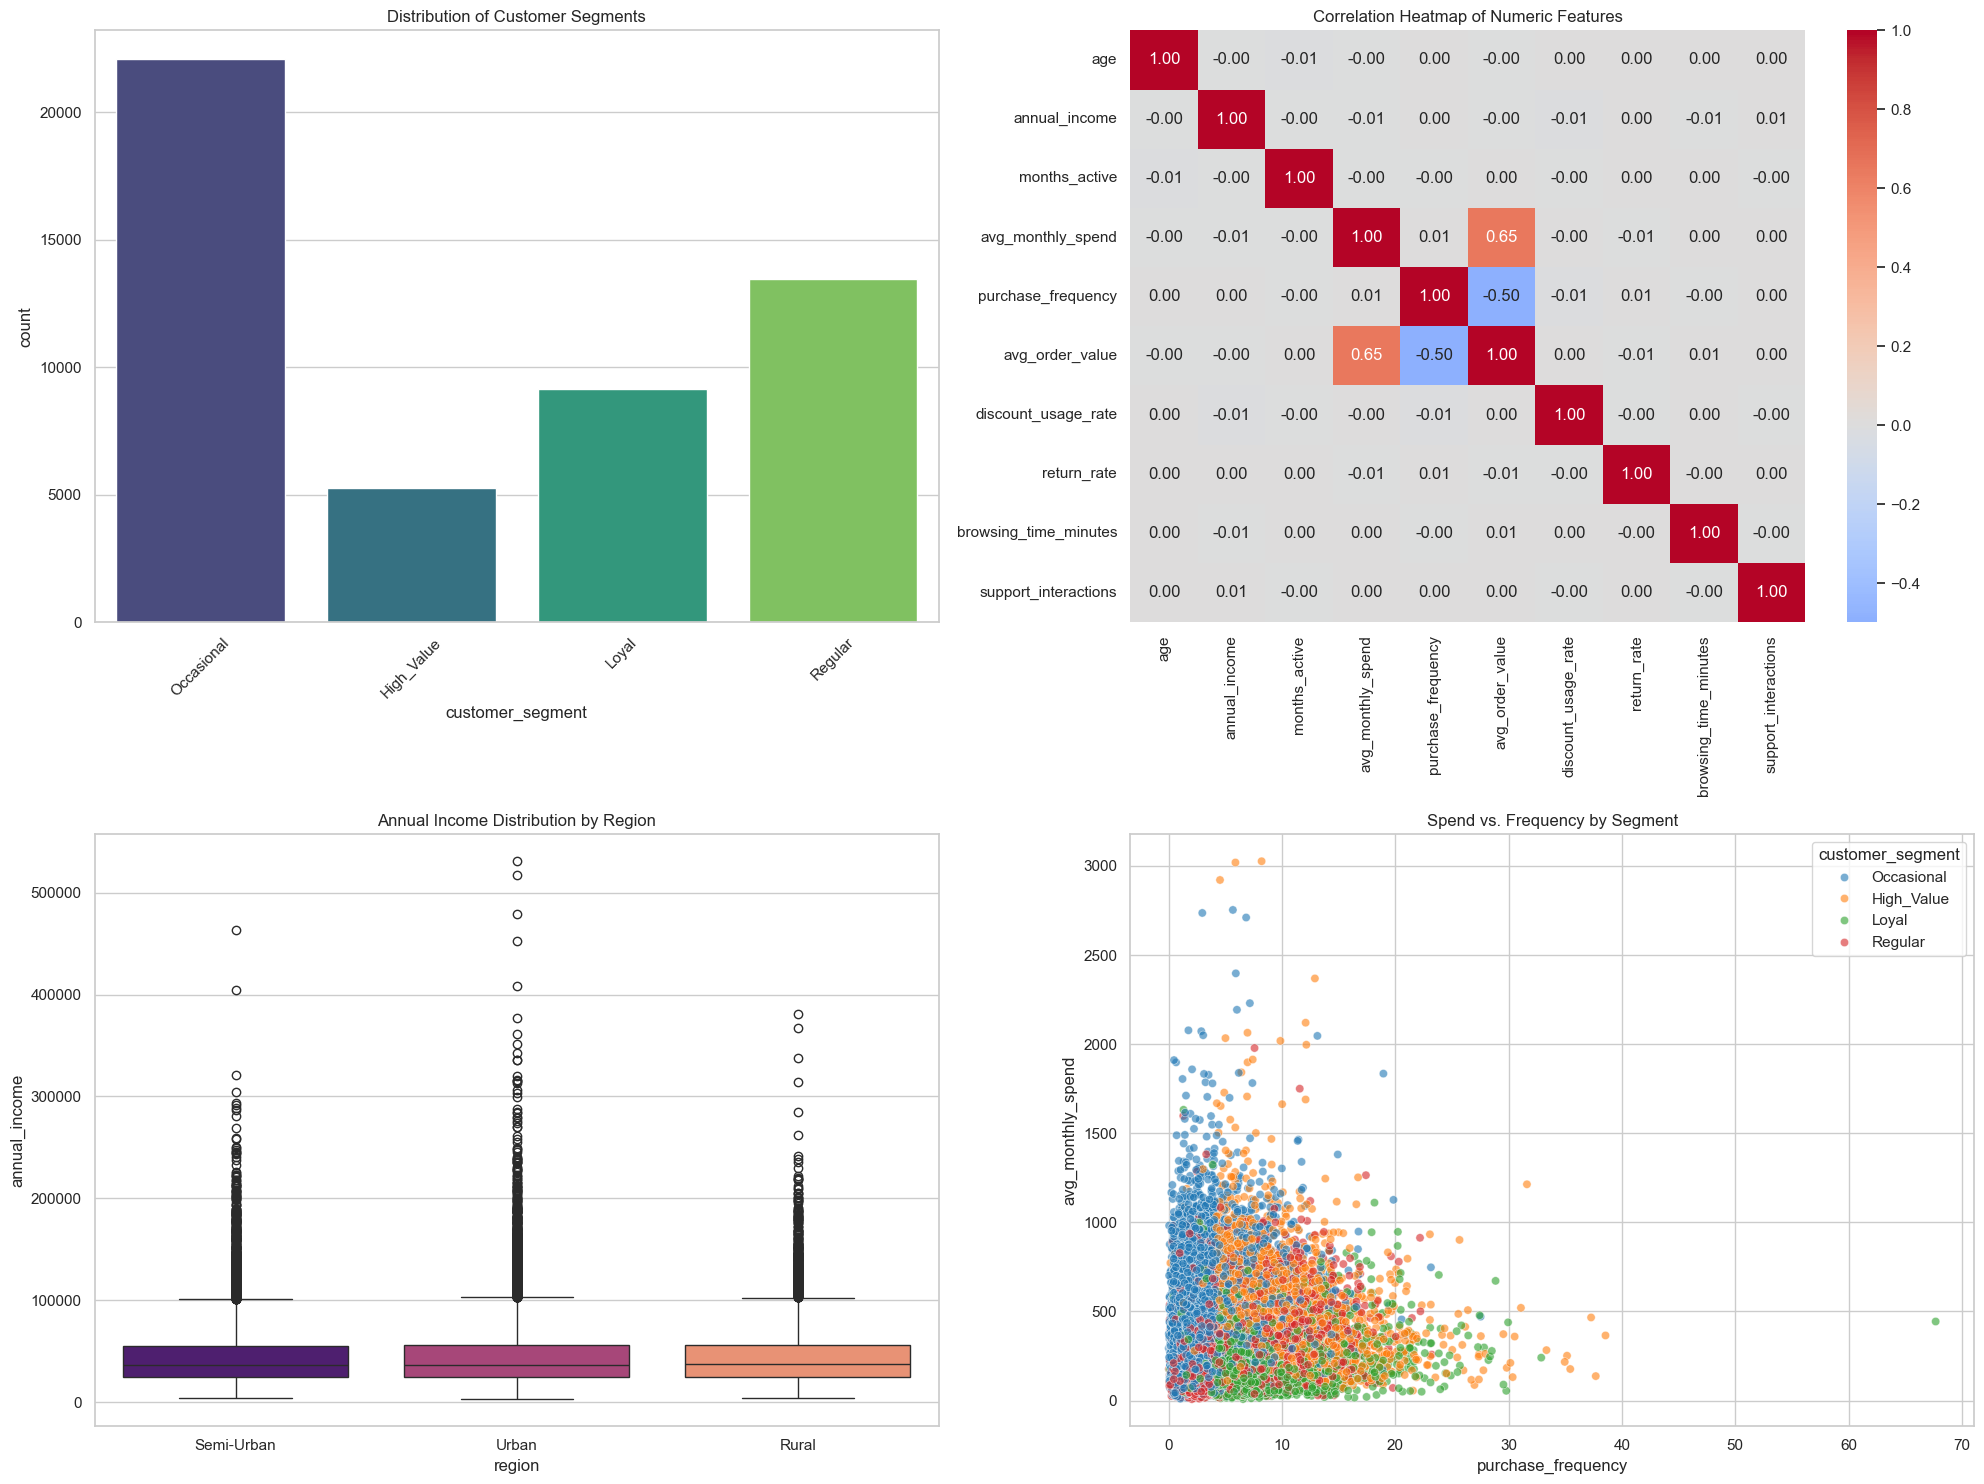

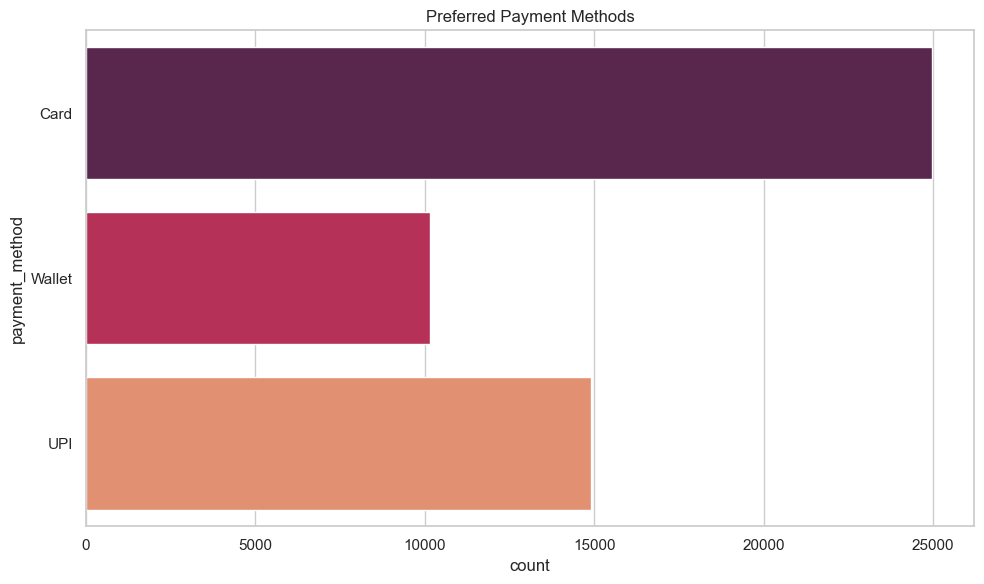

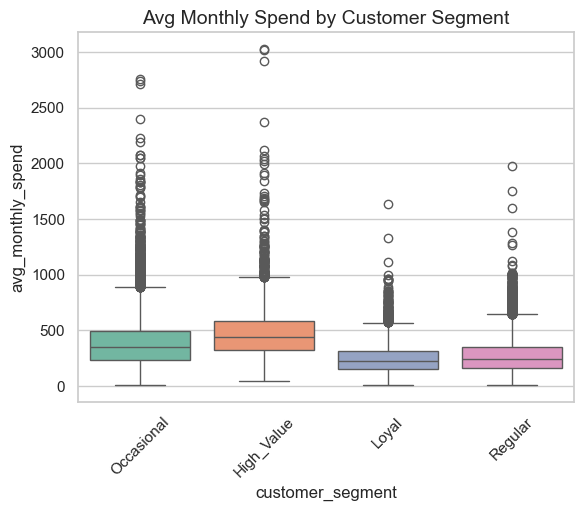

In [4]:
# --- EDA (Summary Statistics) ---
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nDataset Info:")
df.info()
print("\nSummary Statistics:")
print(df.describe())

# --- Visualization ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 15))

# 1. Distribution of Customer Segments
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='customer_segment', hue='customer_segment', palette='viridis', legend=False)
plt.title('Distribution of Customer Segments')
plt.xticks(rotation=45)

# 2. Correlation Heatmap for Numeric Features
plt.subplot(2, 2, 2)
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['customer_id'], errors='ignore')
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')

# 3. Annual Income by Region
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='region', y='annual_income', hue='region', palette='magma', legend=False)
plt.title('Annual Income Distribution by Region')

# 4. Average Monthly Spend vs. Purchase Frequency (Scatter Plot)
plt.subplot(2, 2, 4)
sns.scatterplot(data=df, x='purchase_frequency', y='avg_monthly_spend', hue='customer_segment', palette='tab10', alpha=0.6)
plt.title('Spend vs. Frequency by Segment')

plt.tight_layout()

# Display payment method distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='payment_method', hue='payment_method', palette='rocket', legend=False)
plt.title('Preferred Payment Methods')
plt.tight_layout()

# Average monthly spend by customer segment
plt.figure()
sns.boxplot(x='customer_segment', y='avg_monthly_spend', data=df, palette='Set2')
plt.title('Avg Monthly Spend by Customer Segment', fontsize=14)
plt.xticks(rotation=45)
plt.show()


## DEALING WITH MISSING VALUES

In [5]:
# FIRST LETS REMOVE IF ANY DUPLICATED ROW
df = df.drop_duplicates()
# CHECK IF ANY MISSING VALUE EXIST
print("Mising values in the following columns")
for colum in df.columns:
    numero_total_nulos = df[colum].isna().sum()
    print(colum,": ", numero_total_nulos,",type: ", df[colum].dtype)
    if(numero_total_nulos != 0):
        for type_of_client in df["customer_segment"].unique():
            numero_de_nulos_tipo_cliente = df[df["customer_segment"] == type_of_client][colum].isna().sum()
            print(f"          {type_of_client}: {numero_de_nulos_tipo_cliente}, {(numero_de_nulos_tipo_cliente*100/numero_total_nulos).round(2)}%")  
"""
- Razonamiento inicial de los missing values y por que hay missing values
- annual_income: Gente que no quiere responder la pregunta
- avg_monthly_spend: Al principio pensamos que eran clientes que no habia hecho ninguna compra aunpero viendo 
                    alguno de ellos nos dimos cuenta de que no, supondremos que simplemente han sido errores de extraccion
- purchase_frequency: error en recopilacion de datos
- discount_usage_rate: error en recopilacion de datos o quizas simplemente son clientes que no han usado nunca descuentos 
                    (viendo la cantidad de gente que es suponemos que es lo primero)
- return_rate, support_interactions: basicamente lo mismo
- browsing_time_minutes: error de recopilacion

IMPORTANTE TODOS LOS MISSING VALUES SON NUMERICOS, CREAREMOS UN LINEAR REGRESSION PARA LIDIAR CON ELLOS
"""


Mising values in the following columns
customer_id :  0 ,type:  int64
age :  0 ,type:  int64
annual_income :  3075 ,type:  float64
          Occasional: 1331, 43.28%
          High_Value: 330, 10.73%
          Loyal: 571, 18.57%
          Regular: 843, 27.41%
months_active :  0 ,type:  int64
avg_monthly_spend :  2520 ,type:  float64
          Occasional: 1089, 43.21%
          High_Value: 261, 10.36%
          Loyal: 477, 18.93%
          Regular: 693, 27.5%
purchase_frequency :  1979 ,type:  float64
          Occasional: 890, 44.97%
          High_Value: 200, 10.11%
          Loyal: 352, 17.79%
          Regular: 537, 27.13%
avg_order_value :  0 ,type:  float64
discount_usage_rate :  2549 ,type:  float64
          Occasional: 1143, 44.84%
          High_Value: 267, 10.47%
          Loyal: 485, 19.03%
          Regular: 654, 25.66%
return_rate :  2487 ,type:  float64
          Occasional: 1082, 43.51%
          High_Value: 270, 10.86%
          Loyal: 473, 19.02%
          Regular: 662

'\n- Razonamiento inicial de los missing values y por que hay missing values\n- annual_income: Gente que no quiere responder la pregunta\n- avg_monthly_spend: Al principio pensamos que eran clientes que no habia hecho ninguna compra aunpero viendo \n                    alguno de ellos nos dimos cuenta de que no, supondremos que simplemente han sido errores de extraccion\n- purchase_frequency: error en recopilacion de datos\n- discount_usage_rate: error en recopilacion de datos o quizas simplemente son clientes que no han usado nunca descuentos \n                    (viendo la cantidad de gente que es suponemos que es lo primero)\n- return_rate, support_interactions: basicamente lo mismo\n- browsing_time_minutes: error de recopilacion\n\nIMPORTANTE TODOS LOS MISSING VALUES SON NUMERICOS, CREAREMOS UN LINEAR REGRESSION PARA LIDIAR CON ELLOS\n'

Para lidiar con los outliers haremos un linear regresion para imputar los valores, para ello primero dividiremos entre train y test. Elaboraremos el modelo con la parte de train y despues imputaremos con ese mismo modelo en la de test.

## Probamos a hacer un imputador

In [6]:
X = df.copy().drop(columns=["customer_segment","customer_id"]) 
y = df["customer_segment"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
train_df = X_train.copy()
train_df[y.name] = y_train.values
test_df = X_test.copy()
test_df[y.name] = y_test.values

In [7]:
cols_num = X_train.select_dtypes(include=[np.number]).columns

# ─────────────────────────────────────────────
# PREPARACIÓN COMÚN — sin _seg_enc, imputación ciega
# ─────────────────────────────────────────────
train_iter = X_train[cols_num].copy()
test_iter  = X_test[cols_num].copy()

cols_iter = list(cols_num)  # ya no hay _seg_enc

# Filas completamente reales (sin ningún NaN)
train_completo = train_iter.dropna()

# ─────────────────────────────────────────────
# MÉTODO A — Mediana general
# ─────────────────────────────────────────────

median_general = X_train[cols_num].median()

train_A = X_train[cols_num].fillna(median_general)
test_A  = X_test[cols_num].fillna(median_general)
# ─────────────────────────────────────────────
# MÉTODO B — IterativeImputer (BayesianRidge)
# ─────────────────────────────────────────────
imp_B = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,
    random_state=42,
    imputation_order="ascending"
)
imp_B.fit(train_completo)

train_B = pd.DataFrame(imp_B.transform(train_iter), columns=cols_iter, index=train_iter.index)
test_B  = pd.DataFrame(imp_B.transform(test_iter),  columns=cols_iter, index=test_iter.index)


# ─────────────────────────────────────────────
# MÉTODO C — IterativeImputer (GradientBoosting)
# ─────────────────────────────────────────────
imp_C = IterativeImputer(
    estimator=GradientBoostingRegressor(n_estimators=50, random_state=42),
    max_iter=5,
    random_state=42
)
imp_C.fit(train_completo)

train_C = pd.DataFrame(imp_C.transform(train_iter), columns=cols_iter, index=train_iter.index)
test_C  = pd.DataFrame(imp_C.transform(test_iter),  columns=cols_iter, index=test_iter.index)


# ─────────────────────────────────────────────
# MÉTODO D — KNN con escalado/desescalado
# ─────────────────────────────────────────────
scaler = StandardScaler()
train_completo_scaled = scaler.fit_transform(train_completo)

train_iter_scaled = scaler.transform(train_iter)
test_iter_scaled  = scaler.transform(test_iter)

imp_D = KNNImputer(n_neighbors=100, weights="distance")
imp_D.fit(train_completo_scaled)

train_D = pd.DataFrame(
    scaler.inverse_transform(imp_D.transform(train_iter_scaled)),
    columns=cols_iter, index=train_iter.index
)
test_D = pd.DataFrame(
    scaler.inverse_transform(imp_D.transform(test_iter_scaled)),
    columns=cols_iter, index=test_iter.index
)


# ─────────────────────────────────────────────
# EVALUACIÓN
# ─────────────────────────────────────────────
def evaluar(X_tr, X_te, y_tr, y_te, nombre):
    clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_te)
    acc   = accuracy_score(y_te, preds)
    print(f"\n{'='*50}")
    print(f"  {nombre}  |  Accuracy: {acc:.4f}")
    print('='*50)
    print(classification_report(y_te, preds))
    return acc

acc_A = evaluar(train_A, test_A, y_train, y_test, "A — Mediana por grupo ")
acc_B = evaluar(train_B,   test_B,   y_train, y_test, "B — IterativeImputer BayesianRidge ")
acc_C = evaluar(train_C,   test_C,   y_train, y_test, "C — IterativeImputer GradientBoosting ")
acc_D = evaluar(train_D,   test_D,   y_train, y_test, "D — KNN ")

resumen = pd.DataFrame({
    "Método":   ["A — Mediana grupo", "B — Iterative (Bayes)", "C — Iterative (GBM)", "D — KNN"],
    "Accuracy": [acc_A, acc_B, acc_C, acc_D]
}).sort_values("Accuracy", ascending=False)

print("\n RANKING FINAL")
print(resumen.to_string(index=False))


  A — Mediana por grupo   |  Accuracy: 0.7455
              precision    recall  f1-score   support

  High_Value       0.84      0.80      0.82      1055
       Loyal       0.85      0.78      0.82      1832
  Occasional       0.75      0.83      0.79      4422
     Regular       0.62      0.55      0.59      2691

    accuracy                           0.75     10000
   macro avg       0.77      0.74      0.75     10000
weighted avg       0.74      0.75      0.74     10000


  B — IterativeImputer BayesianRidge   |  Accuracy: 0.7412
              precision    recall  f1-score   support

  High_Value       0.83      0.79      0.81      1055
       Loyal       0.84      0.79      0.81      1832
  Occasional       0.75      0.82      0.79      4422
     Regular       0.62      0.56      0.59      2691

    accuracy                           0.74     10000
   macro avg       0.76      0.74      0.75     10000
weighted avg       0.74      0.74      0.74     10000


  C — IterativeImputer

In [7]:
#AQUI FALTA POR RELLENAR CON EL MEJOR
#ahora ya no tenemos missing values


train_df[cols_num] = pd.DataFrame(
    imp_C.transform(train_df[cols_num]),
    columns=cols_num,
    index=train_df.index
)
test_df[cols_num] = pd.DataFrame(
    imp_C.transform(test_df[cols_num]),
    columns=cols_num,
    index=test_df.index
)

Despues de unas cuantas iteraciones no he sido capaz de hacer un modelo que prediga mejor todas las variables numericas que faltan que la mediana

## FEATURE ENGENIERING

Crearemos algunas features mas que nos parezcan que pueden tener relevacia

In [8]:
for df_ in [train_df, test_df]:
    df_['spend_per_browse'] = df_['avg_monthly_spend'] / df_['browsing_time_minutes']
    df_['monthly_value'] = df_['avg_order_value'] * df_['purchase_frequency']
    df_['net_purchase_rate'] = 1 - df_['return_rate']  # df → df_
    df_['loyalty_score'] = df_['months_active'] * df_['purchase_frequency']
    df_['clv_proxy'] = df_['avg_monthly_spend'] * df_['months_active'] * df_['net_purchase_rate']  

In [9]:
X_train = train_df.copy().drop(columns=["customer_segment"]) 
X_test = test_df.copy().drop(columns=["customer_segment"]) 
y_train = train_df["customer_segment"]
y_test = test_df["customer_segment"]

## OUTLIERS?

Mirando manualmente los datos vemos valores extrañamente altos y bajos (sobre todo altos) por ejemplo alguien tiene un average de compra de 68 veces por mes y ademas de eso gasta poco.

IDEA DEL CHAT, COMO NO PODEMOS IR VIENDO DE UN EN UNO LOS 50K CLIENTES: 

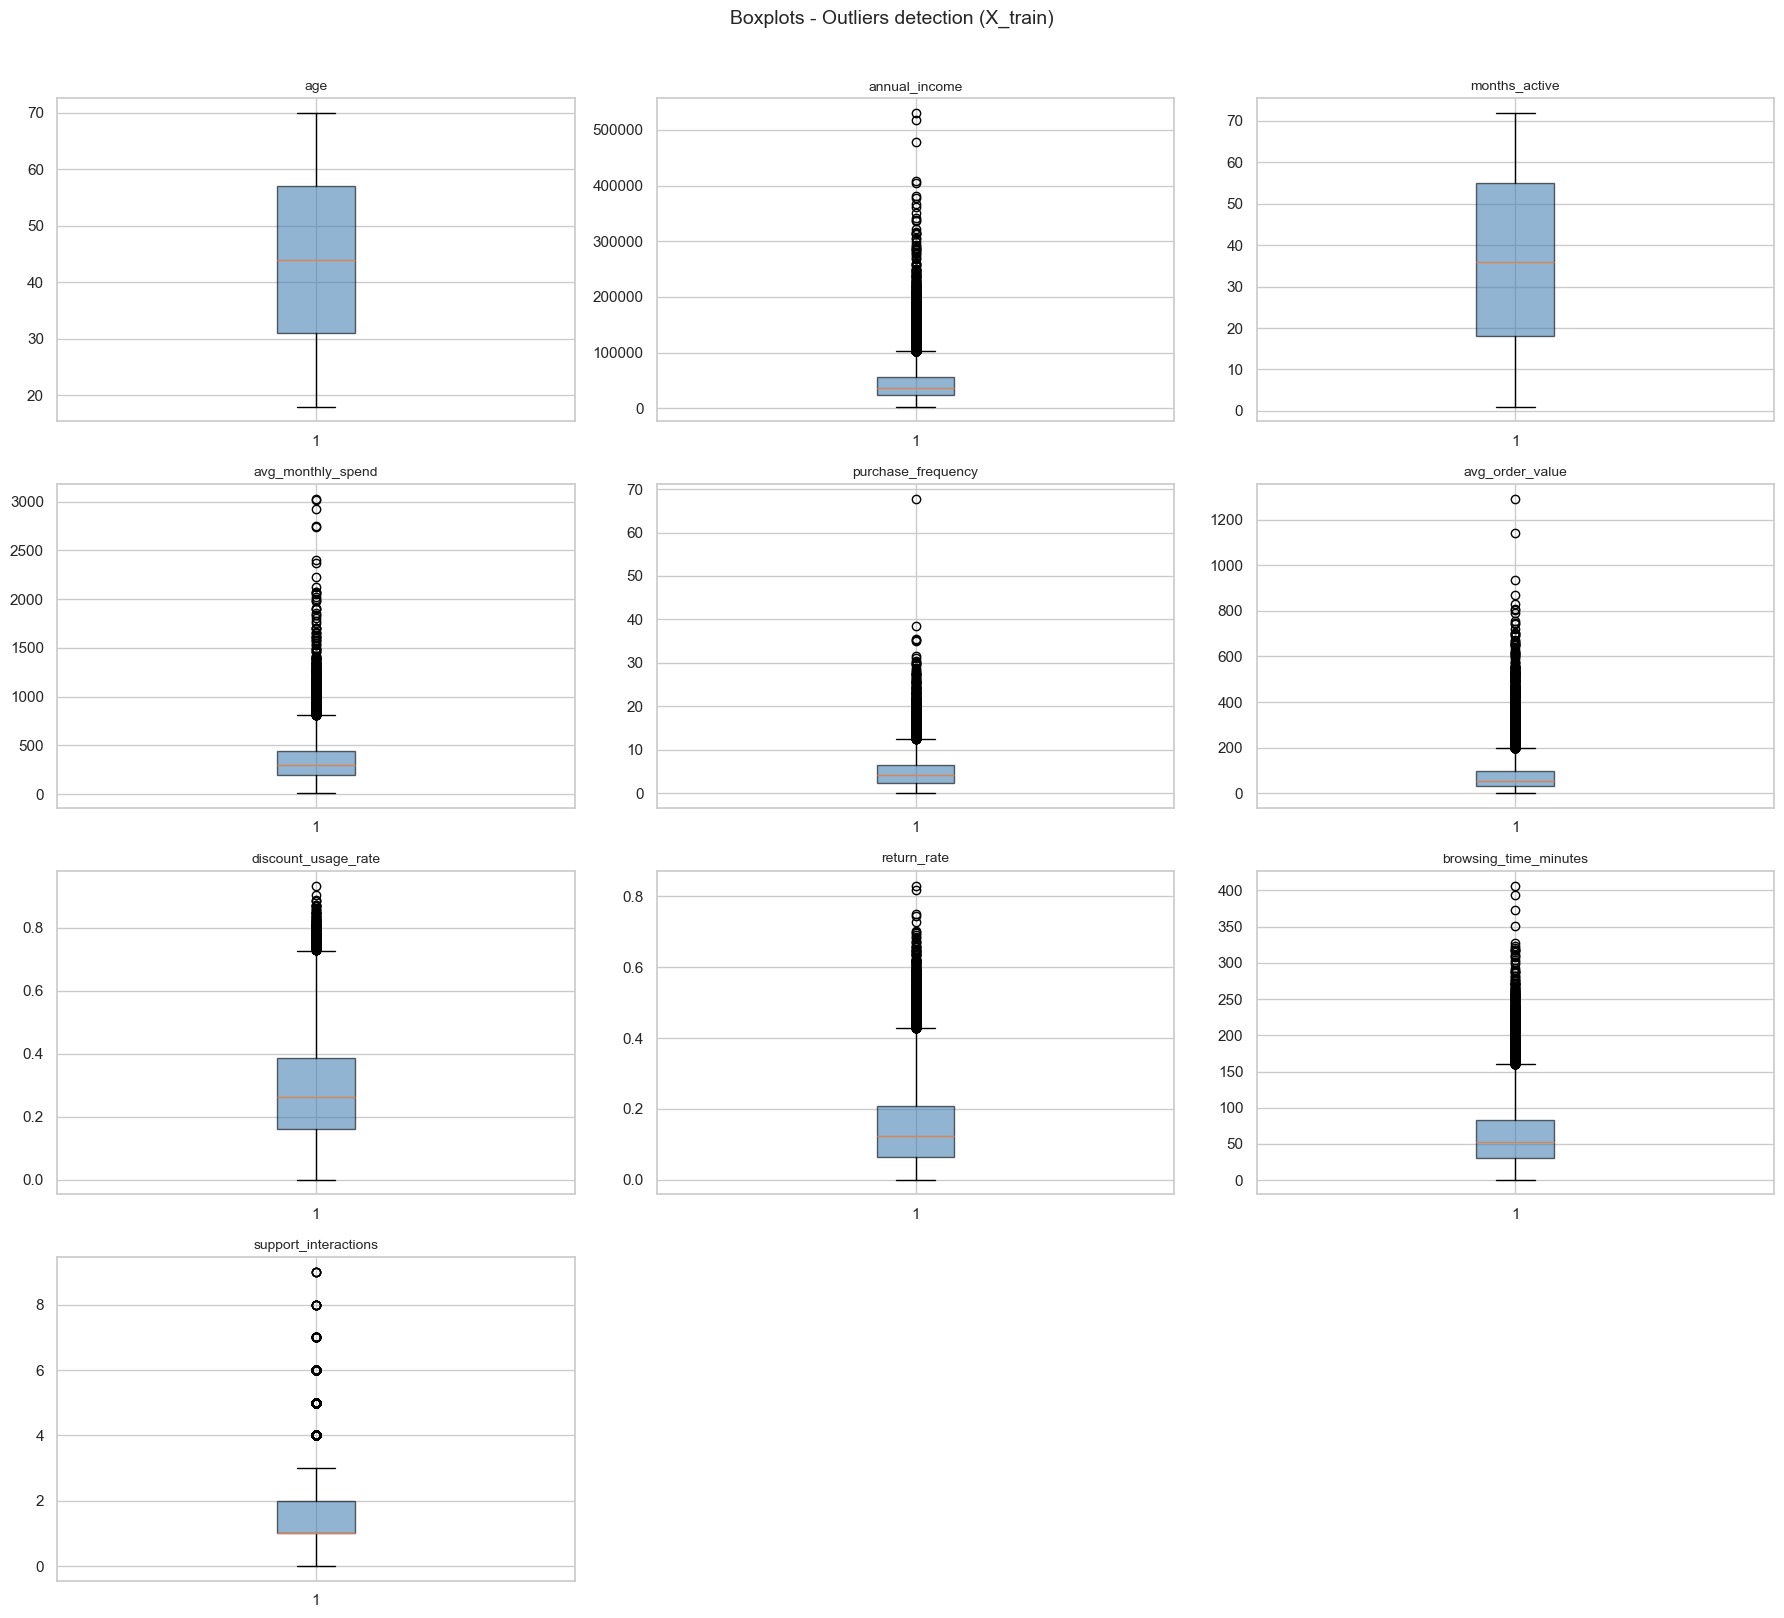

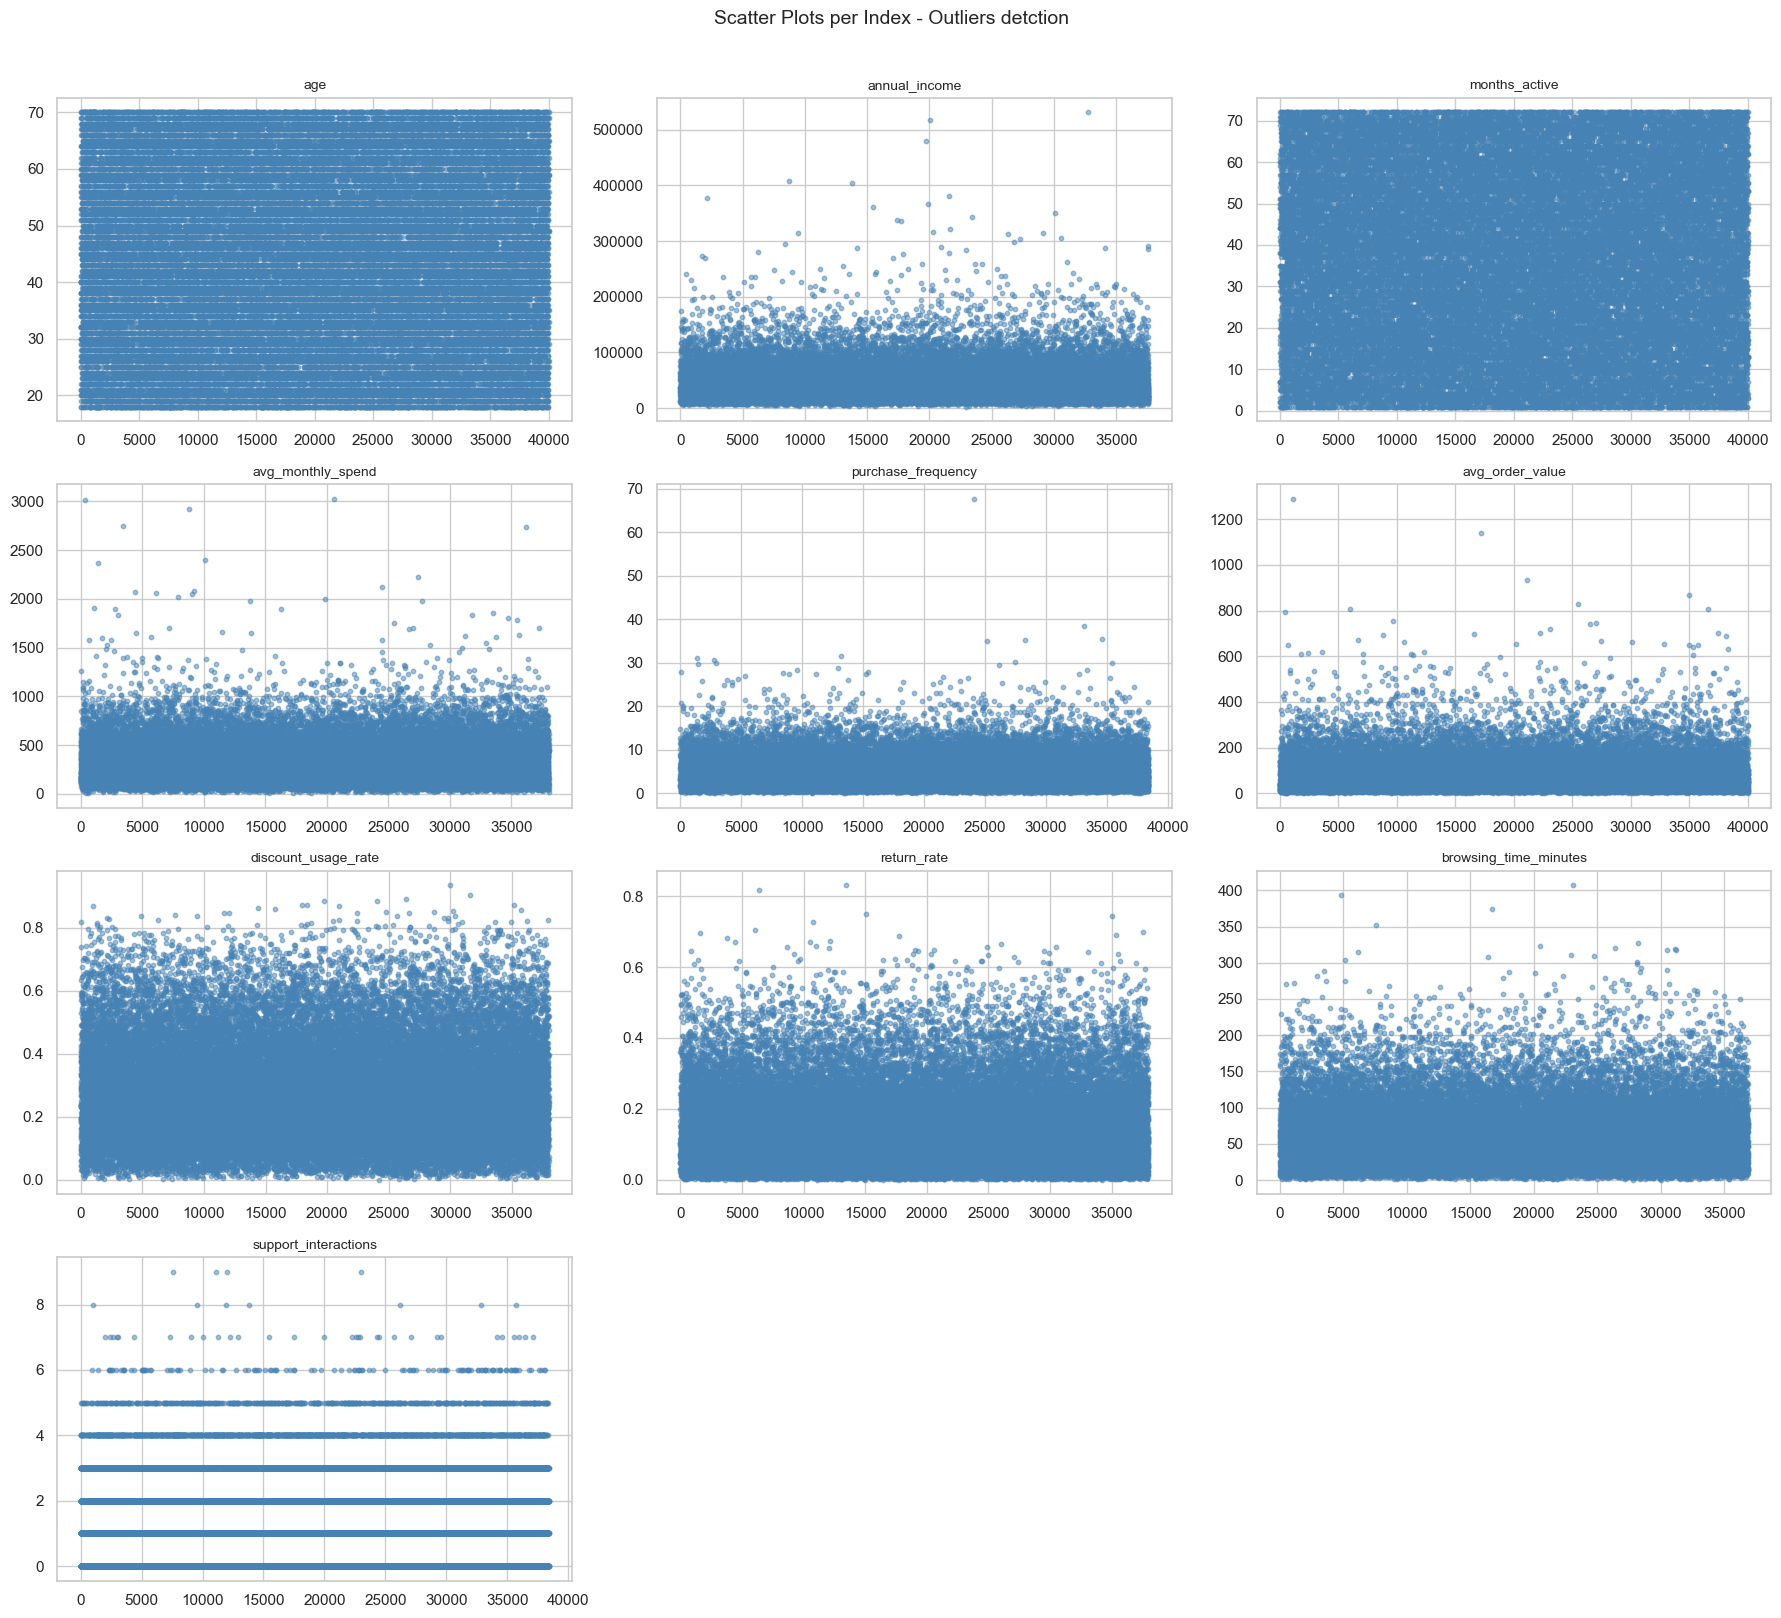

In [11]:
## OUTLIERS - VISUALIZATION

cols_to_check = X_train.select_dtypes(include=[np.number]).columns.tolist()

n_cols = 3
n_rows = -(-len(cols_to_check) // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_to_check):
    axes[i].boxplot(X_train[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Outliers detection (X_train)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_to_check):
    axes[i].scatter(range(len(X_train[col].dropna())), X_train[col].dropna(), 
                    alpha=0.5, color='steelblue', s=10)
    axes[i].set_title(col, fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Scatter Plots per Index - Outliers detction', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
## OUTLIERS - IQR CAPPING

cols_to_cap = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Calculamos límites SOLO con train
iqr_limits = {}
for col in cols_to_cap:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_limits[col] = (lower, upper)
    print(f"{col}: [{lower:.3f}, {upper:.3f}]")

# Aplicamos capping a train y test con los mismos límites
for col in cols_to_cap:
    lower, upper = iqr_limits[col]
    X_train[col] = X_train[col].clip(lower=lower, upper=upper)
    X_test[col]  = X_test[col].clip(lower=lower, upper=upper)

print(" Capping aplicado correctamente en train y test")

age: [-8.000, 96.000]
annual_income: [-17983.216, 96983.628]
months_active: [-37.500, 110.500]
avg_monthly_spend: [-179.761, 811.343]
purchase_frequency: [-3.566, 12.561]
avg_order_value: [-68.347, 199.411]
discount_usage_rate: [-0.154, 0.702]
return_rate: [-0.137, 0.408]
browsing_time_minutes: [-36.987, 149.453]
support_interactions: [-0.500, 3.500]
spend_per_browse: [-7.953, 21.319]
monthly_value: [-155.626, 638.292]
net_purchase_rate: [0.592, 1.137]
loyalty_score: [-232.826, 535.265]
clv_proxy: [-12835.197, 30915.601]
 Capping aplicado correctamente en train y test


## Análisis de Outliers
A tener en cuenta chavales
### Variables sin problema
- **age**
- **months_active**
- **discount_usage_rate**
- **return_rate**
- **support_interactions**

### Variables con outliers severos

- **annual_income**  
  El límite superior del IQR da ~96.870, pero en el boxplot se ven valores hasta 500.000+.  
  Son outliers muy extremos, probablemente clientes VIP reales.

- **avg_monthly_spend**, **avg_order_value**, **monthly_value**, **clv_proxy**  
  Misma historia: colas muy largas hacia arriba.  
  Tiene sentido porque unos pocos clientes gastan muchísimo.

- **purchase_frequency**  
  Alguien comprando **60+ veces al mes** es claramente anómalo.

One-Hot Encoding

In [12]:
## ENCODING - ONE HOT ENCODING

cat_cols = ['payment_method', 'region']

# fit SOLO con train, transform en ambos
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)

# Aplicamos las mismas columnas a test (puede que get_dummies genere columnas distintas)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Columnas tras OHE:", X_train.shape[1])
print(X_train.filter(like='payment').head(3))
print(X_train.filter(like='region').head(3))

Columnas tras OHE: 19
       payment_method_UPI  payment_method_Wallet
34427               False                  False
24959               False                  False
16407                True                  False
       region_Semi-Urban  region_Urban
34427              False         False
24959               True         False
16407              False         False


In [ ]:

le = LabelEncoder()

# fit SOLO con train
y_train = le.fit_transform(y_train)
y_test  = le.transform(y_test)

print("Clases:", le.classes_)
print("Ejemplo:", list(zip(y_train[:5], y_test[:5])))

y_train= pd.Series(y_train, name="customer_segment")
y_test= pd.Series(y_test, name="customer_segment")

Clases: ['High_Value' 'Loyal' 'Occasional' 'Regular']
Ejemplo: [(np.int64(1), np.int64(2)), (np.int64(2), np.int64(3)), (np.int64(2), np.int64(1)), (np.int64(3), np.int64(2)), (np.int64(1), np.int64(2))]


Scaler


In [14]:

# Las columnas booleanas del OHE no se escalan
cols_to_scale = X_train.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()

# fit SOLO con train
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print("Media tras escalar (debe ser ~0):")
print(X_train[cols_to_scale].mean().round(3))
print("\nDesviación estándar (debe ser ~1):")
print(X_train[cols_to_scale].std().round(3))

Media tras escalar (debe ser ~0):
age                      0.0
annual_income            0.0
months_active           -0.0
avg_monthly_spend        0.0
purchase_frequency      -0.0
avg_order_value         -0.0
discount_usage_rate     -0.0
return_rate              0.0
browsing_time_minutes   -0.0
support_interactions     0.0
spend_per_browse         0.0
monthly_value           -0.0
net_purchase_rate        0.0
loyalty_score           -0.0
clv_proxy                0.0
dtype: float64

Desviación estándar (debe ser ~1):
age                      1.0
annual_income            1.0
months_active            1.0
avg_monthly_spend        1.0
purchase_frequency       1.0
avg_order_value          1.0
discount_usage_rate      1.0
return_rate              1.0
browsing_time_minutes    1.0
support_interactions     1.0
spend_per_browse         1.0
monthly_value            1.0
net_purchase_rate        1.0
loyalty_score            1.0
clv_proxy                1.0
dtype: float64


Rearmamos el X_train y X_test

In [ ]:
"""
# GUARDAMOS
os.makedirs("../Train_test_split", exist_ok=True)

X_train.to_csv("../Train_test_split/X_train.csv",index=False)
X_test.to_csv("../Train_test_split/X_test.csv",index=False)
y_train.to_csv("../Train_test_split/y_train.csv", index=False)
y_test.to_csv("../Train_test_split/y_test.csv", index=False)
"""
